# Disease Prediction Model - Preparation and Preprocessing

## 1. Loading the data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import arff

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import warnings

from pathlib import Path

warnings.filterwarnings("ignore")

In [2]:
root = Path().resolve().parent

diabetes_path = root / "data" / "raw" / "diabetes_raw.csv"
df_diabetes = pd.read_csv(diabetes_path)

hypertension_path = root / "data" / "raw" / "hypertension_raw.csv"
df_hypertension = pd.read_csv(hypertension_path)

heart_disease_path = root / "data" / "raw" / "heart_disease_raw.csv"
df_heart_disease = pd.read_csv(heart_disease_path)

* Now all the datasets are loaded and they are all available in CSV format. This makes it easier to read both for myself and using pandas.

## 2. Data Cleaning

* Now we can begin with data cleaning. Since we have multiple datasets at play here for each disease, we can clean all datasets of each disease one by one. This will provide a good structure and also make it easier to merge diseases that have multiple datasets. All datasets will follow the below dataset cleaning pipeline:
    - Data inspection
    - Standardizing column names
    - Removing duplicates
    - Fixing data types
    - Handling missing values
    - Handling outliers
    - Final check and saving dataset

### 2.1 Diabetes dataset

Inspecting the dataset


In [3]:
df_diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


**"diabetes" is our target variable**

In [4]:
df_diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df_diabetes.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
df_diabetes.describe(include="all")

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000,100000.000000,100000.00000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,No Info,NaN,NaN,NaN,NaN
freq,58552,NaN,NaN,NaN,35816,NaN,NaN,NaN,NaN
mean,NaN,41.885856,0.07485,0.039420,NaN,27.320767,5.527507,138.058060,0.085000
std,NaN,22.516840,0.26315,0.194593,NaN,6.636783,1.070672,40.708136,0.278883
min,NaN,0.080000,0.00000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,NaN,24.000000,0.00000,0.000000,NaN,23.630000,4.800000,100.000000,0.000000
50%,NaN,43.000000,0.00000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,NaN,60.000000,0.00000,0.000000,NaN,29.580000,6.200000,159.000000,0.000000


The above dataset already has a good structure. There aren't any glaring problems. Let's move on to the next step and standardize column names.

In [7]:
df_diabetes.columns = df_diabetes.columns.str.lower()
df_diabetes.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

Since we are independently planning to check hypertension and heart disease in our model, we don't need those columns. We can simply drop those to keep consistency.

In [8]:
df_diabetes = df_diabetes.drop(columns=["hypertension", "heart_disease"])
df_diabetes.columns

Index(['gender', 'age', 'smoking_history', 'bmi', 'hba1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='str')

Now we can check for and remove duplicates.

In [9]:
df_diabetes.duplicated().sum()

np.int64(4345)

In [10]:
df_diabetes = df_diabetes.drop_duplicates()
df_diabetes.duplicated().sum()

np.int64(0)

Duplicate values have been removed. Now we can move onto fixing data types.

Gender and smoking history are strings but they have almost binary values, just in the form of strings. Thus, converting them to category will make it much more efficient.

In [11]:
df_diabetes["gender"] = df_diabetes["gender"].astype("category")
df_diabetes["smoking_history"] = df_diabetes["smoking_history"].astype("category")

In [12]:
df_diabetes["smoking_history"].unique()

['never', 'No Info', 'current', 'former', 'ever', 'not current']
Categories (6, str): ['No Info', 'current', 'ever', 'former', 'never', 'not current']

Smoking history column has some inconsistent and ambiguous categories. There is no clear meaning as to what the difference is between `ever`, `former` and `not current`. For the purpose of this project we will assume those mean that the patient was a former smoker. We will also assume that patients with `no info` are non smokers.

In [13]:
df_diabetes["smoking_history"] = df_diabetes["smoking_history"].map({
    "never": "Never", "No Info": "Never", "current": "Current",
    "former": "Former", "ever": "Former", "not current": "Former"
})
df_diabetes["smoking_history"].unique()
df_diabetes["smoking_history"] = df_diabetes["smoking_history"].astype("category")

Age is a float when it should just be an int.

In [14]:
df_diabetes["age"] = df_diabetes["age"].astype(int)

We do not need to handle any missing values as there are none. We can directly move on to handling outliers.

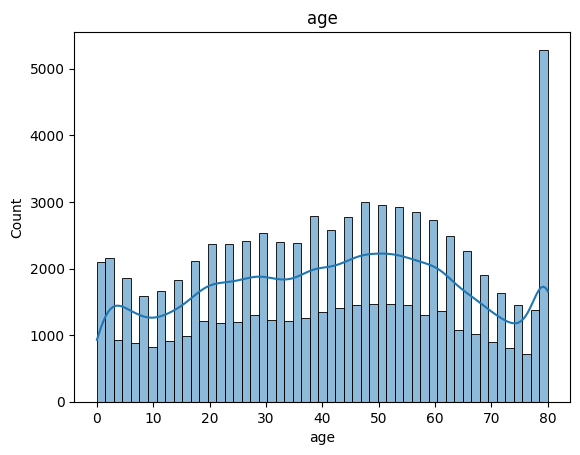

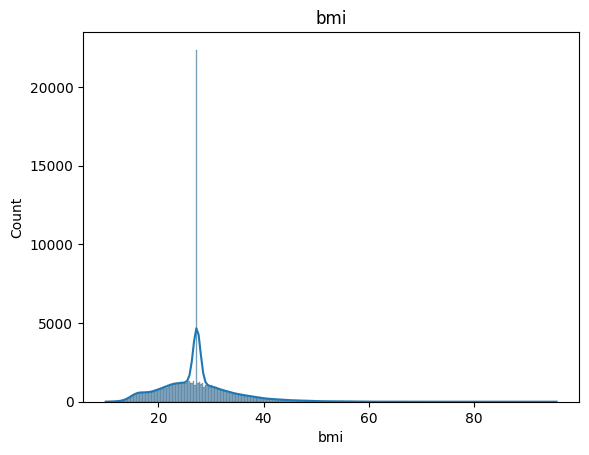

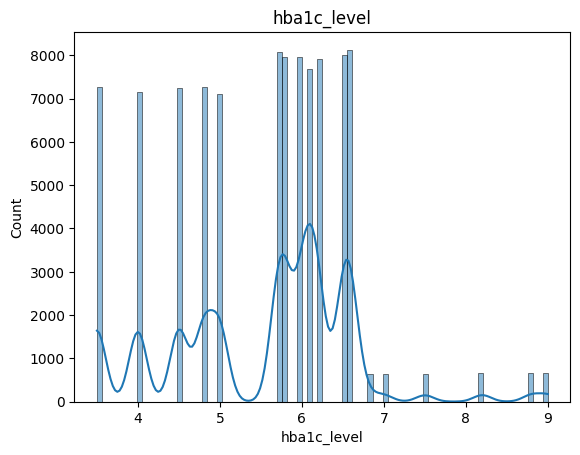

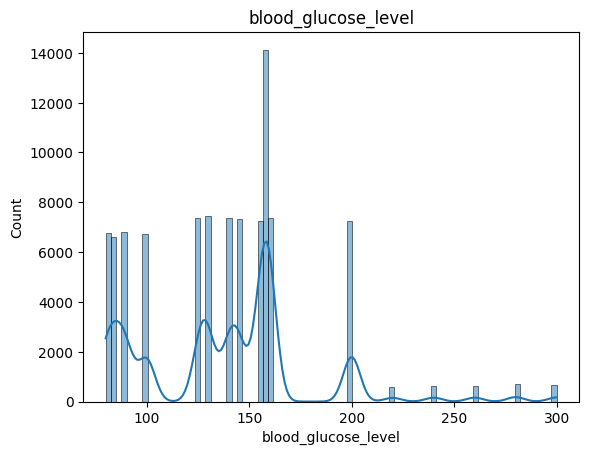

In [15]:
numerical_cols = ["age", "bmi", "hba1c_level", "blood_glucose_level"]

for col in numerical_cols:
    sns.histplot(df_diabetes[col], kde=True)
    plt.title(col)
    plt.show()

Age has a spike towards the end of the spectrum but this could very well be because of the massive impact that age has on diagnosis of diabetes, hence we will leave it that way.

BMI, however, has few values that look out of the scope of a reasonable medical context. It will be beneficial to our model to cap the BMI to something like 60 which is more reasonable.

In [16]:
count = len(df_diabetes[df_diabetes["bmi"] > 60])
df_diabetes = df_diabetes[df_diabetes["bmi"] <= 60]
print(f"Deleted {count} rows.")

Deleted 115 rows.


Hemoglobin A1c level looks reasonable. We will leave it as is.<br>
Blood glucose level, while highly right skewed, looks reasonable from the context that most patients in the dataset have diabetes.

Performing final checks and saving the cleaned dataset.

In [17]:
df_diabetes.info()

<class 'pandas.DataFrame'>
Index: 95540 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               95540 non-null  category
 1   age                  95540 non-null  int64   
 2   smoking_history      95540 non-null  category
 3   bmi                  95540 non-null  float64 
 4   hba1c_level          95540 non-null  float64 
 5   blood_glucose_level  95540 non-null  int64   
 6   diabetes             95540 non-null  int64   
dtypes: category(2), float64(2), int64(3)
memory usage: 4.6 MB


In [18]:
df_diabetes.describe()

,age,bmi,hba1c_level,blood_glucose_level,diabetes
count,95540.000000,95540.000000,95540.000000,95540.000000,95540.000000
mean,41.644913,27.274164,5.533093,138.211817,0.088183
std,22.443183,6.644865,1.072927,40.909770,0.283562
min,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,23.360000,4.800000,100.000000,0.000000
50%,43.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,29.870000,6.200000,159.000000,0.000000
max,80.000000,60.000000,9.000000,300.000000,1.000000


In [19]:
diabetes_processed_path = root / "data" / "processed" / "diabetes.csv"
df_diabetes.to_csv(diabetes_processed_path)

### 2.2 Hypertension dataset

Inspecting the dataset

In [20]:
df_hypertension.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   str    
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   str    
 7   Family_History    1985 non-null   str    
 8   Exercise_Level    1985 non-null   str    
 9   Smoking_Status    1985 non-null   str    
 10  Has_Hypertension  1985 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 170.7 KB


**"has_hypertension" is the target variable**

In [21]:
df_hypertension.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [22]:
df_hypertension.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [23]:
df_hypertension.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

Standardizing column names

In [24]:
df_hypertension.columns = df_hypertension.columns.str.lower()
df_hypertension.columns

Index(['age', 'salt_intake', 'stress_score', 'bp_history', 'sleep_duration',
       'bmi', 'medication', 'family_history', 'exercise_level',
       'smoking_status', 'has_hypertension'],
      dtype='str')

Removing duplicates if any

In [25]:
df_hypertension.duplicated().sum()

np.int64(0)

Converting columns to categorical columns for efficiency 

In [26]:
categorical_cols = [
    "bp_history", "medication", "family_history",
    "exercise_level", "smoking_status", "has_hypertension"
]

for col in categorical_cols:
    df_hypertension[col] = df_hypertension[col].astype("category")

Looking at the earlier inspection of the dataset, we can see that only medication has null values which are most likely values showing an empty string because the patient does not take medication. Hence we can replace the empty values with a value like "None" indicating that the patient takes no medication.

In [27]:
df_hypertension["medication"] = df_hypertension["medication"].cat.add_categories(["None"])
df_hypertension["medication"] = df_hypertension["medication"].fillna("None")
df_hypertension.isnull().sum()

age                 0
salt_intake         0
stress_score        0
bp_history          0
sleep_duration      0
bmi                 0
medication          0
family_history      0
exercise_level      0
smoking_status      0
has_hypertension    0
dtype: int64

Now, lets look at handling outliers.

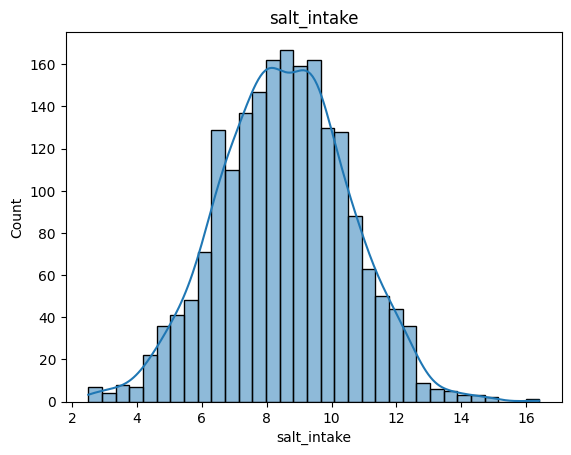

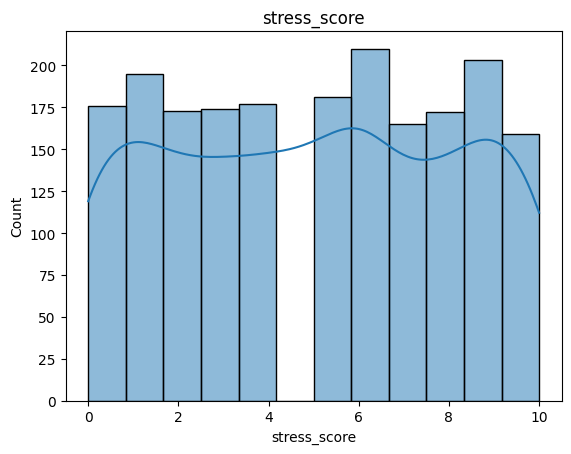

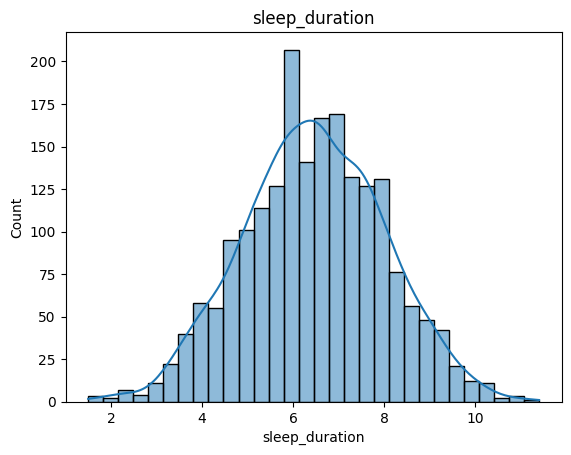

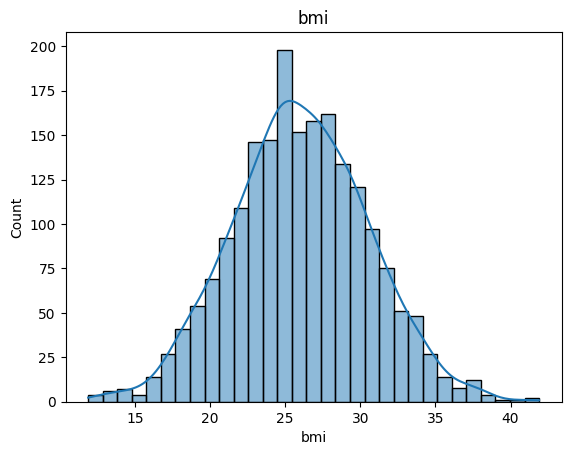

In [28]:
numerical_cols = ["salt_intake", "stress_score", "sleep_duration", "bmi"]

for col in numerical_cols:
    sns.histplot(df_hypertension[col], kde=True)
    plt.title(col)
    plt.show()

All the values look reasonable from a medical standpoint, hence no further action is required.

Final checks and saving the processed dataset

In [29]:
df_hypertension.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1985 non-null   int64   
 1   salt_intake       1985 non-null   float64 
 2   stress_score      1985 non-null   int64   
 3   bp_history        1985 non-null   category
 4   sleep_duration    1985 non-null   float64 
 5   bmi               1985 non-null   float64 
 6   medication        1985 non-null   category
 7   family_history    1985 non-null   category
 8   exercise_level    1985 non-null   category
 9   smoking_status    1985 non-null   category
 10  has_hypertension  1985 non-null   category
dtypes: category(6), float64(3), int64(2)
memory usage: 89.8 KB


In [30]:
df_hypertension.describe()

,age,salt_intake,stress_score,sleep_duration,bmi
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [31]:
hypertension_processed_path = root / "data" / "processed" / "hypertension.csv"
df_hypertension.to_csv(hypertension_processed_path)

### 2.3 Heart disease dataset

Inspecting the dataset.

In [32]:
df_heart_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

**"Heart Disease Status" is the target variable**

In [33]:
df_heart_disease.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [34]:
df_heart_disease.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [35]:
df_heart_disease.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

Standardizing column names

In [36]:
df_heart_disease.columns = (
    df_heart_disease.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)
df_heart_disease.columns

Index(['age', 'gender', 'blood_pressure', 'cholesterol_level',
       'exercise_habits', 'smoking', 'family_heart_disease', 'diabetes', 'bmi',
       'high_blood_pressure', 'low_hdl_cholesterol', 'high_ldl_cholesterol',
       'alcohol_consumption', 'stress_level', 'sleep_hours',
       'sugar_consumption', 'triglyceride_level', 'fasting_blood_sugar',
       'crp_level', 'homocysteine_level', 'heart_disease_status'],
      dtype='str')

Removing duplicates if any

In [37]:
df_heart_disease.duplicated().sum()

np.int64(0)

A lot of the columns can be stored as the category dtype, hence increasing efficiency.

In [38]:
categorical_cols = [
    "gender", "exercise_habits", "smoking", "family_heart_disease",
    "low_hdl_cholesterol", "high_ldl_cholesterol", "alcohol_consumption", 
    "stress_level", "sugar_consumption", "heart_disease_status"
]

for col in categorical_cols:
    df_heart_disease[col] = df_heart_disease[col].astype("category")

Since our model will incorporate the probabilities of the patient having diabetes and hypertension from the two smaller models, we need to cast the `diabetes` and `high_blood_pressure` columns as float so that the model can be trained to accept float values as well. Also we will change the column name from `high_blood_pressure` to `hypertension` for consistency.

In [39]:
category_map = {"Yes": 1.0, "No": 0.0}

df_heart_disease["diabetes"] = df_heart_disease["diabetes"].map(category_map).astype(float)
df_heart_disease["high_blood_pressure"] = df_heart_disease["high_blood_pressure"].map(category_map).astype(float)
df_heart_disease = df_heart_disease.rename(columns={"high_blood_pressure": "hypertension"})
df_heart_disease.columns

Index(['age', 'gender', 'blood_pressure', 'cholesterol_level',
       'exercise_habits', 'smoking', 'family_heart_disease', 'diabetes', 'bmi',
       'hypertension', 'low_hdl_cholesterol', 'high_ldl_cholesterol',
       'alcohol_consumption', 'stress_level', 'sleep_hours',
       'sugar_consumption', 'triglyceride_level', 'fasting_blood_sugar',
       'crp_level', 'homocysteine_level', 'heart_disease_status'],
      dtype='str')

Handling missing values

In [40]:
df_heart_disease["alcohol_consumption"].unique()

['High', 'Medium', 'Low', NaN]
Categories (3, str): ['High', 'Low', 'Medium']

There is an abnormally high amount of missing values in the alcohol consumption column of the dataset. While this may look like unentered values, upon taking a closer look at the data entered into this field, we can see that the null values indicate that the patient does not consume any alcohol. Hence we can give it a value, say, "None" to keep the data consistent. This is a form of constant imputation.

In [41]:
df_heart_disease["alcohol_consumption"] = df_heart_disease["alcohol_consumption"].cat.add_categories(["None"])
df_heart_disease["alcohol_consumption"] = df_heart_disease["alcohol_consumption"].fillna("None")
df_heart_disease["alcohol_consumption"].unique()

['High', 'Medium', 'Low', 'None']
Categories (4, str): ['High', 'Low', 'Medium', 'None']

For the remaining columns with null values, since the amount of null values is low (0.2% to 0.3%), we can impute those values using:
* Median imputation for numerical columns
* Mode imputation for categorical columns.

Median imputation

In [42]:
numerical_cols = [
    "age", "blood_pressure", "cholesterol_level", "bmi",
    "sleep_hours", "triglyceride_level",
    "fasting_blood_sugar", "crp_level", "homocysteine_level"
]

for col in numerical_cols:
    df_heart_disease[col] = df_heart_disease[col].fillna(df_heart_disease[col].median())

Mode imputation (we don't want the target variable to be affected)

In [43]:
#remembering to add diabetes and hypertension columns, as although they are floats they are technically categorical at this stage
categorical_cols.extend(["diabetes", "hypertension"])

for col in categorical_cols:
    if col == "heart_disease_status":
        continue

    df_heart_disease[col] = df_heart_disease[col].fillna(df_heart_disease[col].mode()[0])

In [44]:
df_heart_disease.isnull().sum()

age                     0
gender                  0
blood_pressure          0
cholesterol_level       0
exercise_habits         0
smoking                 0
family_heart_disease    0
diabetes                0
bmi                     0
hypertension            0
low_hdl_cholesterol     0
high_ldl_cholesterol    0
alcohol_consumption     0
stress_level            0
sleep_hours             0
sugar_consumption       0
triglyceride_level      0
fasting_blood_sugar     0
crp_level               0
homocysteine_level      0
heart_disease_status    0
dtype: int64

Handling outliers

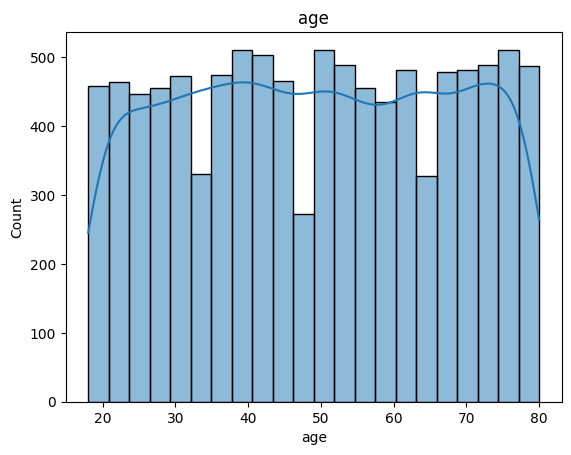

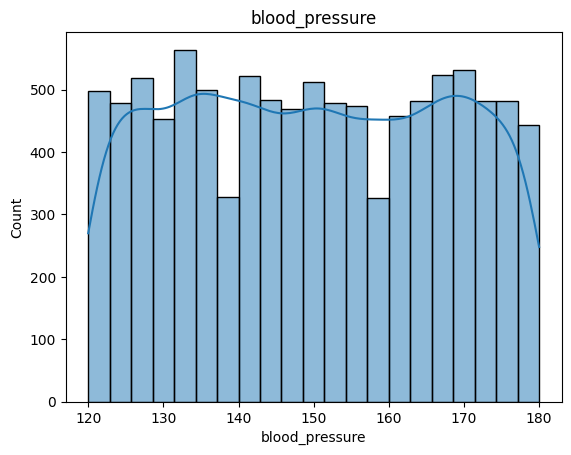

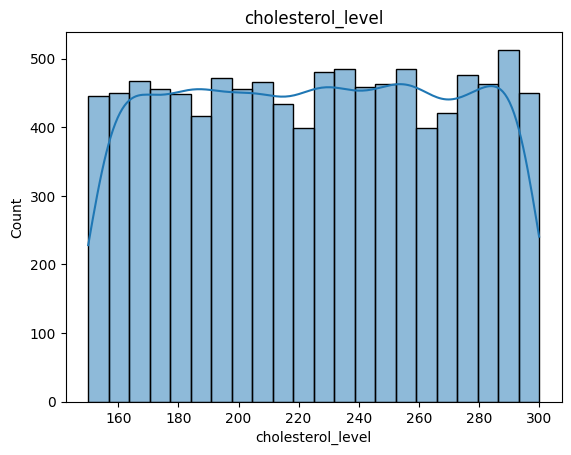

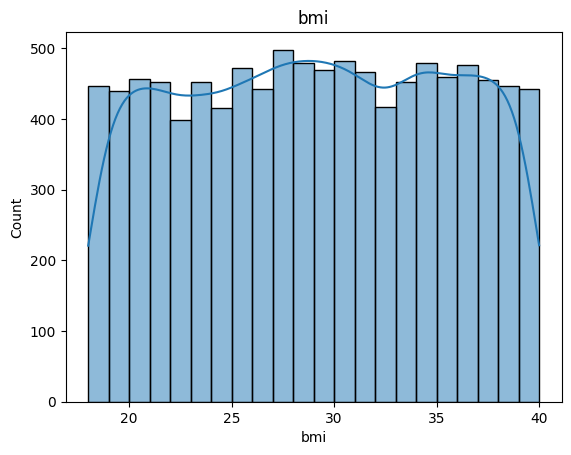

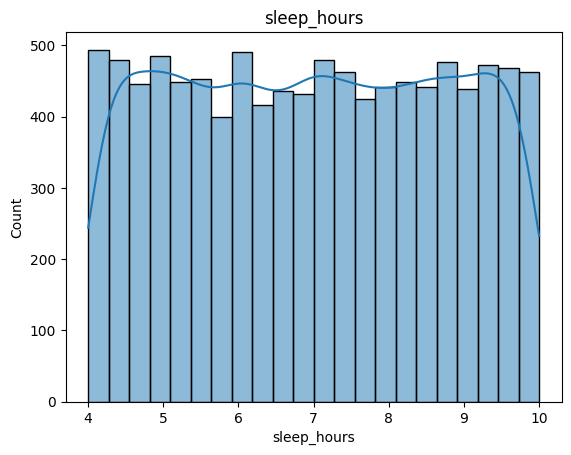

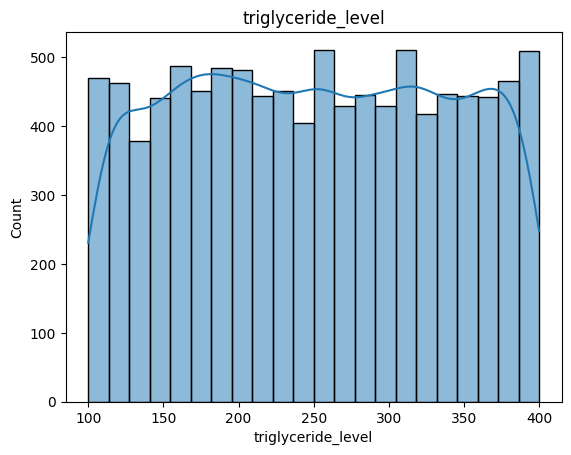

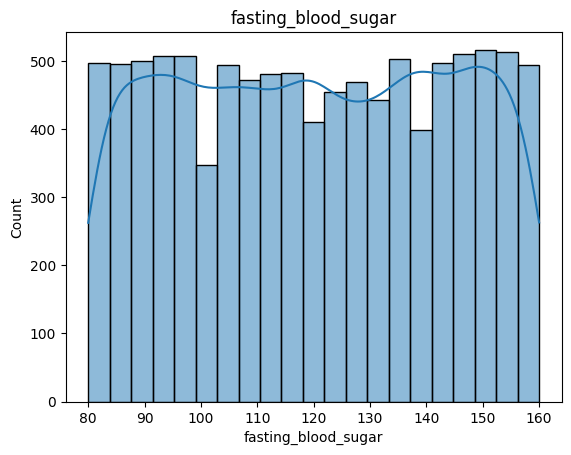

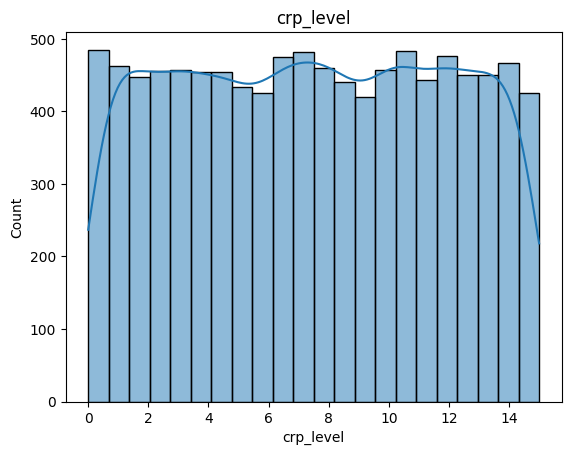

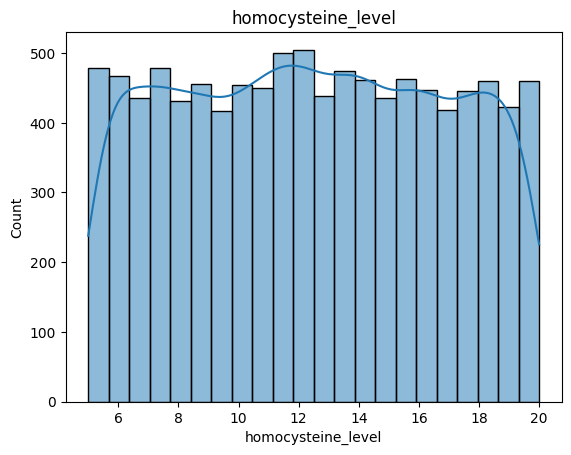

In [45]:
for col in numerical_cols:
    sns.histplot(df_heart_disease[col], kde=True)
    plt.title(col)
    plt.show()

From the above graphs we can see that all the features follow a proper distribution and no real outliers are present. Hence we will keep all of them as is.

Final verification and saving the dataset

In [46]:
df_heart_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   10000 non-null  float64 
 1   gender                10000 non-null  category
 2   blood_pressure        10000 non-null  float64 
 3   cholesterol_level     10000 non-null  float64 
 4   exercise_habits       10000 non-null  category
 5   smoking               10000 non-null  category
 6   family_heart_disease  10000 non-null  category
 7   diabetes              10000 non-null  float64 
 8   bmi                   10000 non-null  float64 
 9   hypertension          10000 non-null  float64 
 10  low_hdl_cholesterol   10000 non-null  category
 11  high_ldl_cholesterol  10000 non-null  category
 12  alcohol_consumption   10000 non-null  category
 13  stress_level          10000 non-null  category
 14  sleep_hours           10000 non-null  float64 
 15  sugar_consumpt

In [47]:
df_heart_disease.describe()

,age,blood_pressure,cholesterol_level,diabetes,bmi,hypertension,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,homocysteine_level
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,49.295400,149.758200,225.427300,0.495200,29.077274,0.504800,6.991359,250.732500,120.141900,7.472200,12.456177
std,18.167574,17.556268,43.510401,0.500002,6.300156,0.500002,1.751002,86.953962,23.558053,4.334601,4.319100
min,18.000000,120.000000,150.000000,0.000000,18.002837,0.000000,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,0.000000,23.668887,0.000000,5.455288,176.000000,99.000000,3.681800,8.729771
50%,49.000000,150.000000,226.000000,0.000000,29.079492,1.000000,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,1.000000,34.509009,1.000000,8.527938,326.000000,141.000000,11.244879,16.130968
max,80.000000,180.000000,300.000000,1.000000,39.996954,1.000000,9.999952,400.000000,160.000000,14.997087,19.999037


In [48]:
heart_disease_processed_path = root / "data" / "processed" / "heart_disease.csv"
df_heart_disease.to_csv(heart_disease_processed_path)

## 3. Feature Engineering

### 3.1 Diabetes dataset

In [49]:
df_diabetes.info()

<class 'pandas.DataFrame'>
Index: 95540 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               95540 non-null  category
 1   age                  95540 non-null  int64   
 2   smoking_history      95540 non-null  category
 3   bmi                  95540 non-null  float64 
 4   hba1c_level          95540 non-null  float64 
 5   blood_glucose_level  95540 non-null  int64   
 6   diabetes             95540 non-null  int64   
dtypes: category(2), float64(2), int64(3)
memory usage: 4.6 MB


For the scale of our project, we do not need 100,000 entries. We can trim it down to 10,000 entries to match the other datasets in our project. Also, since we have so many unused entries at our disposal, we can make sure that the target variable is perfectly balanced. This will make EDA and model building much simpler.

In [50]:
df_majority = df_diabetes[df_diabetes["diabetes"] == 0].sample(n=5000, random_state=42)
df_minority = df_diabetes[df_diabetes["diabetes"] == 1].sample(n=5000, random_state=42)
df_diabetes = pd.concat([df_majority, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True)

We can engineer a feature to keep track of the patient's metabolic status to better help the model understand how those factors interact with the probability of having diabetes. First, we need to standardize values.

In [51]:
scaler = StandardScaler()

df_diabetes[["bmi_z", "hba1c_z", "glucose_z"]] = scaler.fit_transform(
    df_diabetes[["bmi", "hba1c_level", "blood_glucose_level"]]
)

df_diabetes["metabolic_index"] = (df_diabetes["bmi_z"] + df_diabetes["hba1c_z"] + df_diabetes["glucose_z"])/3

df_diabetes = df_diabetes.drop(columns=["bmi_z", "hba1c_z", "glucose_z"])

In [52]:
df_diabetes["metabolic_index"].describe()

count    1.000000e+04
mean     4.760636e-17
std      6.995307e-01
min     -1.848674e+00
25%     -5.065507e-01
50%     -8.885487e-02
75%      4.894372e-01
max      2.651449e+00
Name: metabolic_index, dtype: float64

### 3.2 Hypertension dataset

In [53]:
df_hypertension.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1985 non-null   int64   
 1   salt_intake       1985 non-null   float64 
 2   stress_score      1985 non-null   int64   
 3   bp_history        1985 non-null   category
 4   sleep_duration    1985 non-null   float64 
 5   bmi               1985 non-null   float64 
 6   medication        1985 non-null   category
 7   family_history    1985 non-null   category
 8   exercise_level    1985 non-null   category
 9   smoking_status    1985 non-null   category
 10  has_hypertension  1985 non-null   category
dtypes: category(6), float64(3), int64(2)
memory usage: 89.8 KB


We can engineer a feature to indicate the risk of the patient due to their lifestyle habits. This will take lifestyle factors such as sleep duration, smoking status and exercise level. The value of this feature will be between 0 and 3, with 0 indicating low risk and 3 indicating high risk.

To achieve this, first we will create 3 temporary features to compute the final risk score.

* abnormal_sleep: Calculates a value from 0 to 1 relating to how abnormal a patient's average sleep duration is. 0 indicates normal sleep, 1 indicates highly &nbsp;abnormal sleep. Note that both lack of and too much sleep can increase risk of hypertension.

* is_smoker: A value from 0 to 1 indicating whether a person smokes or not.

* low_exercise: Calculates a value from 0 to 1 indicating how low a patient exercises.

In [54]:
def calculate_abnormal_sleep(sleep):
    ideal_sleep = 8

    diff = abs(sleep - ideal_sleep)

    abnormal_score = min(diff/ideal_sleep, 1.0)

    return abnormal_score

def calculate_low_exercise(level):
    if level == "Low":
        return 1

    elif level == "Moderate":
        return 0.5

    elif level == "High":
        return 0

df_hypertension["abnormal_sleep"] = df_hypertension["sleep_duration"].apply(calculate_abnormal_sleep)
df_hypertension["is_smoker"] = df_hypertension["smoking_status"].apply(lambda x: 1 if x == "Smoker" else 0).astype(int)
df_hypertension["low_exercise"] = df_hypertension["exercise_level"].apply(calculate_low_exercise).astype(int)

Now we can create the `lifestyle_risk_score` feature and get rid of the temporary features.

In [55]:
df_hypertension["lifestyle_risk_score"] = (
    df_hypertension["abnormal_sleep"] +
    df_hypertension["is_smoker"] +
    df_hypertension["low_exercise"]
)

df_hypertension = df_hypertension.drop(columns=["abnormal_sleep", "is_smoker", "low_exercise"])

In [56]:
df_hypertension["lifestyle_risk_score"].describe()

count    1985.000000
mean        0.982601
std         0.680297
min         0.000000
25%         0.287500
50%         1.100000
75%         1.325000
max         2.812500
Name: lifestyle_risk_score, dtype: float64

### 3.3 Heart disease dataset

In [57]:
df_heart_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   10000 non-null  float64 
 1   gender                10000 non-null  category
 2   blood_pressure        10000 non-null  float64 
 3   cholesterol_level     10000 non-null  float64 
 4   exercise_habits       10000 non-null  category
 5   smoking               10000 non-null  category
 6   family_heart_disease  10000 non-null  category
 7   diabetes              10000 non-null  float64 
 8   bmi                   10000 non-null  float64 
 9   hypertension          10000 non-null  float64 
 10  low_hdl_cholesterol   10000 non-null  category
 11  high_ldl_cholesterol  10000 non-null  category
 12  alcohol_consumption   10000 non-null  category
 13  stress_level          10000 non-null  category
 14  sleep_hours           10000 non-null  float64 
 15  sugar_consumpt

We can engineer a feature to indicate the inflammation risk of a patient as chronic inflammation in the regions near the heart is key to contracting heart disease due to it damaging blood vessels and promoting blood clots. This can be calculated by adding the CRP and Homocysteine levels, which in turn cause inflammation.

In [58]:
df_heart_disease["inflammation_score"] = df_heart_disease["crp_level"] + df_heart_disease["homocysteine_level"]

According to the American Heart Association, metabolic syndrome is a group of conditions that is a prime factor that could potentially lead to heart disease. Primarily metabolic syndrome depends on blood sugar level, triglyceride level and BMI. We can calculate the metabolic syndrome score by adding these features, however blood sugar level contributes more to this syndrome than the other two features, hence we can give it a weight. But before that we need to standardize the values.

In [59]:
scaler = StandardScaler()

df_heart_disease[["bmi_z", "tg_z", "fbs_z"]] = scaler.fit_transform(
    df_heart_disease[["bmi", "triglyceride_level", "fasting_blood_sugar"]]
)

df_heart_disease["metabolic_syndrome_score"] = (
    0.30 * df_heart_disease["bmi_z"] +
    0.30 * df_heart_disease["tg_z"] +
    0.40 * df_heart_disease["fbs_z"]
)

df_heart_disease = df_heart_disease.drop(columns=["bmi_z", "tg_z", "fbs_z"])

In [60]:
df_heart_disease.describe()

,age,blood_pressure,cholesterol_level,diabetes,bmi,hypertension,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,homocysteine_level,inflammation_score,metabolic_syndrome_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,49.295400,149.758200,225.427300,0.495200,29.077274,0.504800,6.991359,250.732500,120.141900,7.472200,12.456177,19.928378,-1.421085e-16
std,18.167574,17.556268,43.510401,0.500002,6.300156,0.500002,1.751002,86.953962,23.558053,4.334601,4.319100,6.088191,5.869183e-01
min,18.000000,120.000000,150.000000,0.000000,18.002837,0.000000,4.000605,100.000000,80.000000,0.003647,5.000236,5.157813,-1.629748e+00
25%,34.000000,134.000000,187.000000,0.000000,23.668887,0.000000,5.455288,176.000000,99.000000,3.681800,8.729771,15.686678,-4.117909e-01
50%,49.000000,150.000000,226.000000,0.000000,29.079492,1.000000,7.003252,250.000000,120.000000,7.472164,12.409395,19.944743,9.919143e-03
75%,65.000000,165.000000,263.000000,1.000000,34.509009,1.000000,8.527938,326.000000,141.000000,11.244879,16.130968,24.314288,4.187715e-01
max,80.000000,180.000000,300.000000,1.000000,39.996954,1.000000,9.999952,400.000000,160.000000,14.997087,19.999037,34.808378,1.572333e+00


## 4. Data Transformation

Now we will be preparing the data for model training. Data transformation involves two main steps:
> Label encoding <br>
> Feature scaling

### 4.1 Diabetes dataset

In [61]:
df_diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               10000 non-null  category
 1   age                  10000 non-null  int64   
 2   smoking_history      10000 non-null  category
 3   bmi                  10000 non-null  float64 
 4   hba1c_level          10000 non-null  float64 
 5   blood_glucose_level  10000 non-null  int64   
 6   diabetes             10000 non-null  int64   
 7   metabolic_index      10000 non-null  float64 
dtypes: category(2), float64(3), int64(3)
memory usage: 488.5 KB


The diabetes dataset has two categorical string columns: `gender` and `smoking_history`. We will label-encode these. Then we will scale the continuous numerical features.

In [62]:
diabetes_gender_encoder = LabelEncoder()
diabetes_smoking_encoder = LabelEncoder()

df_diabetes["gender_enc"] = diabetes_gender_encoder.fit_transform(df_diabetes["gender"].astype(str))
df_diabetes["smoking_history_enc"] = diabetes_smoking_encoder.fit_transform(df_diabetes["smoking_history"].astype(str))

df_diabetes = df_diabetes.drop(columns=["gender", "smoking_history"])
df_diabetes.columns = df_diabetes.columns.str.replace("_enc", "")

print("Gender classes:", list(diabetes_gender_encoder.classes_))
print("Smoking history classes:", list(diabetes_smoking_encoder.classes_))
df_diabetes.head()

Gender classes: ['Female', 'Male', 'Other']
Smoking history classes: ['Current', 'Former', 'Never']


,age,bmi,hba1c_level,blood_glucose_level,diabetes,metabolic_index,gender,smoking_history
0,80,26.00,7.5,200,1,0.410140,0,2
1,63,27.32,6.5,158,0,-0.035382,0,2
2,42,27.50,6.6,145,0,-0.076893,0,2
3,35,27.32,5.0,100,0,-0.765127,0,2
4,32,27.32,4.5,90,0,-0.953925,1,2


Now we can scale the numerical features. The `diabetes` and the `metabolic_index` columns are excluded. 

In [63]:
diabetes_scale_cols = ["age", "bmi", "hba1c_level", "blood_glucose_level"]

scaler_diabetes = StandardScaler()
df_diabetes[diabetes_scale_cols] = scaler_diabetes.fit_transform(df_diabetes[diabetes_scale_cols])

df_diabetes[diabetes_scale_cols].describe().round(3)

,age,bmi,hba1c_level,blood_glucose_level
count,10000.000,10000.000,10000.000,10000.000
mean,-0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-2.333,-2.658,-2.075,-1.463
25%,-0.668,-0.512,-0.353,-0.588
50%,0.164,-0.281,-0.040,-0.150
75%,0.811,0.481,0.351,0.637
max,1.366,4.205,2.230,2.387


Saving the transformed dataset

In [64]:
target_col = df_diabetes.pop("diabetes")
df_diabetes["diabetes"] = target_col

diabetes_transformed_path = root / "data" / "processed" / "diabetes_transformed.csv"
df_diabetes.to_csv(diabetes_transformed_path, index=False)
print("Final columns:", list(df_diabetes.columns))
print("Shape:", df_diabetes.shape)
df_diabetes.describe()

Final columns: ['age', 'bmi', 'hba1c_level', 'blood_glucose_level', 'metabolic_index', 'gender', 'smoking_history', 'diabetes']
Shape: (10000, 8)


,age,bmi,hba1c_level,blood_glucose_level,metabolic_index,gender,smoking_history,diabetes
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,-5.968559e-17,2.046363e-16,-3.410605e-17,-2.984279e-17,4.760636e-17,0.447900,1.534300,0.500000
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,6.995307e-01,0.497705,0.676513,0.500025
min,-2.332801e+00,-2.658323e+00,-2.075252e+00,-1.462964e+00,-1.848674e+00,0.000000,0.000000,0.000000
25%,-6.683409e-01,-5.120238e-01,-3.532005e-01,-5.878714e-01,-5.065507e-01,0.000000,1.000000,0.000000
50%,1.638892e-01,-2.813275e-01,-4.010031e-02,-1.503252e-01,-8.885487e-02,0.000000,2.000000,0.500000
75%,8.111793e-01,4.807941e-01,3.512749e-01,6.372582e-01,4.894372e-01,1.000000,2.000000,1.000000
max,1.365999e+00,4.204891e+00,2.229876e+00,2.387443e+00,2.651449e+00,2.000000,2.000000,1.000000


### 4.2 Hypertension dataset

In [65]:
df_hypertension.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   1985 non-null   int64   
 1   salt_intake           1985 non-null   float64 
 2   stress_score          1985 non-null   int64   
 3   bp_history            1985 non-null   category
 4   sleep_duration        1985 non-null   float64 
 5   bmi                   1985 non-null   float64 
 6   medication            1985 non-null   category
 7   family_history        1985 non-null   category
 8   exercise_level        1985 non-null   category
 9   smoking_status        1985 non-null   category
 10  has_hypertension      1985 non-null   category
 11  lifestyle_risk_score  1985 non-null   float64 
dtypes: category(6), float64(4), int64(2)
memory usage: 105.3 KB


As we can see, the hypertension dataset has multiple categorical columns. Out of these, all except `has_hypertension` will be label-encoded, while the `has_hypertension` feature will be binary-encoded (Yes->1, No->0)

In [66]:
hypertension_category_cols = ["bp_history", "medication", "family_history", "exercise_level", "smoking_status"]

hypertension_encoders = {}
for col in hypertension_category_cols:
    le = LabelEncoder()
    df_hypertension[col + "_enc"] = le.fit_transform(df_hypertension[col].astype(str))
    hypertension_encoders[col] = le

df_hypertension["has_hypertension_enc"] = df_hypertension["has_hypertension"].map({"Yes": 1, "No": 0}).astype(int)

df_hypertension = df_hypertension.drop(columns=hypertension_category_cols + ["has_hypertension"])

df_hypertension.columns = df_hypertension.columns.str.replace("_enc", "")

print("Encoded classes:")
for col, le in hypertension_encoders.items():
    print(f"  {col}: {list(le.classes_)}")
df_hypertension.head()

Encoded classes:
  bp_history: ['Hypertension', 'Normal', 'Prehypertension']
  medication: ['ACE Inhibitor', 'Beta Blocker', 'Diuretic', 'None', 'Other']
  family_history: ['No', 'Yes']
  exercise_level: ['High', 'Low', 'Moderate']
  smoking_status: ['Non-Smoker', 'Smoker']


,age,salt_intake,stress_score,sleep_duration,bmi,lifestyle_risk_score,bp_history,medication,family_history,exercise_level,smoking_status,has_hypertension
0,69,8.0,9,6.4,25.8,1.2000,1,3,1,1,0,1
1,32,11.7,10,5.4,23.4,1.3250,1,3,0,1,0,0
2,78,9.5,3,7.1,18.7,0.1125,1,3,0,2,0,0
3,38,10.0,10,4.2,22.1,1.4750,0,0,0,1,0,1
4,41,9.8,1,5.8,16.2,0.2750,2,4,0,2,0,0


Now we can scale the numerical features. The `lifestyle_risk_score` and binary encoded features are excluded from scaling.

In [67]:
hypertension_scale_cols = ["age", "salt_intake", "stress_score", "sleep_duration", "bmi"]

hypertension_scaler = StandardScaler()
df_hypertension[hypertension_scale_cols] = hypertension_scaler.fit_transform(df_hypertension[hypertension_scale_cols])

print("Summary of scaled features:")
df_hypertension[hypertension_scale_cols].describe().round(3)

Summary of scaled features:


,age,salt_intake,stress_score,sleep_duration,bmi
count,1985.000,1985.000,1985.000,1985.000,1985.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.664,-3.024,-1.585,-3.212,-3.129
25%,-0.841,-0.668,-0.948,-0.682,-0.668
50%,-0.018,-0.016,0.007,0.031,-0.026
75%,0.857,0.686,0.962,0.680,0.684
max,1.732,3.945,1.598,3.209,3.521


Saving the transformed dataset

In [68]:
hypertension_transformed_path = root / "data" / "processed" / "hypertension_transformed.csv"
df_hypertension.to_csv(hypertension_transformed_path, index=False)
print("Final columns:", list(df_hypertension.columns))
print("Shape:", df_hypertension.shape)
df_hypertension.describe().round(3)

Final columns: ['age', 'salt_intake', 'stress_score', 'sleep_duration', 'bmi', 'lifestyle_risk_score', 'bp_history', 'medication', 'family_history', 'exercise_level', 'smoking_status', 'has_hypertension']
Shape: (1985, 12)


,age,salt_intake,stress_score,sleep_duration,bmi,lifestyle_risk_score,bp_history,medication,family_history,exercise_level,smoking_status,has_hypertension
count,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.00
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.983,1.026,2.077,0.496,1.135,0.286,0.52
std,1.000,1.000,1.000,1.000,1.000,0.680,0.774,1.293,0.500,0.715,0.452,0.50
min,-1.664,-3.024,-1.585,-3.212,-3.129,0.000,0.000,0.000,0.000,0.000,0.000,0.00
25%,-0.841,-0.668,-0.948,-0.682,-0.668,0.288,0.000,1.000,0.000,1.000,0.000,0.00
50%,-0.018,-0.016,0.007,0.031,-0.026,1.100,1.000,3.000,0.000,1.000,0.000,1.00
75%,0.857,0.686,0.962,0.680,0.684,1.325,2.000,3.000,1.000,2.000,1.000,1.00
max,1.732,3.945,1.598,3.209,3.521,2.812,2.000,4.000,1.000,2.000,1.000,1.00


### 4.3 Heart disease dataset

In [69]:
df_heart_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age                       10000 non-null  float64 
 1   gender                    10000 non-null  category
 2   blood_pressure            10000 non-null  float64 
 3   cholesterol_level         10000 non-null  float64 
 4   exercise_habits           10000 non-null  category
 5   smoking                   10000 non-null  category
 6   family_heart_disease      10000 non-null  category
 7   diabetes                  10000 non-null  float64 
 8   bmi                       10000 non-null  float64 
 9   hypertension              10000 non-null  float64 
 10  low_hdl_cholesterol       10000 non-null  category
 11  high_ldl_cholesterol      10000 non-null  category
 12  alcohol_consumption       10000 non-null  category
 13  stress_level              10000 non-null  category
 14  sl

The heart disease dataset contains several binary categorical columns as well as the `gender` column. These will be encoded. There are few ordinal columns as well in the dataset with values such as 'high', 'medium', 'low', etc. These columns will be encoded using maps. The target variable `heart_disease_status` will be binary-encoded. Numerical features will then be scaled.

Since `diabetes` and `hypertension` features were already converted to float, we do not need re-encoding.

In [70]:
heart_gender_encoder = LabelEncoder()
df_heart_disease["gender_enc"] = heart_gender_encoder.fit_transform(df_heart_disease["gender"].astype(str))

binary_cols = [
    "smoking", "family_heart_disease",
    "low_hdl_cholesterol", "high_ldl_cholesterol",
]

for col in binary_cols:
    df_heart_disease[col + "_enc"] = df_heart_disease[col].map({"Yes": 1, "No": 0}).astype(int)

ordinal_cols = [
    "exercise_habits", "alcohol_consumption", 
    "stress_level", "sugar_consumption"
]
ordinal_col_map = { "None": 0, "Low": 1, "Medium": 2, "High": 3 }

for col in ordinal_cols:
    df_heart_disease[col + "_enc"] = df_heart_disease[col].map(ordinal_col_map).astype(int)

df_heart_disease["heart_disease_status_enc"] = df_heart_disease["heart_disease_status"].map({"Yes": 1, "No": 0}).astype(int)

drop_cols = ["gender", "heart_disease_status"] + binary_cols + ordinal_cols
df_heart_disease = df_heart_disease.drop(columns=drop_cols)
df_heart_disease.columns = df_heart_disease.columns.str.replace("_enc", "")

print("Gender classes:", list(heart_gender_encoder.classes_))
print("Orindal columns map: ")
for k, v in ordinal_col_map.items():
    print(f"\t{k}: {v}")
df_heart_disease.head()

Gender classes: ['Female', 'Male']
Orindal columns map: 
	None: 0
	Low: 1
	Medium: 2
	High: 3


,age,blood_pressure,cholesterol_level,diabetes,bmi,hypertension,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,...,gender,smoking,family_heart_disease,low_hdl_cholesterol,high_ldl_cholesterol,exercise_habits,alcohol_consumption,stress_level,sugar_consumption,heart_disease_status
0,56.0,153.0,155.0,0.0,24.991591,1.0,7.633228,342.0,120.0,12.969246,...,1,1,1,1,0,3,3,2,2,0
1,69.0,146.0,286.0,1.0,25.221799,0.0,8.744034,133.0,157.0,9.355389,...,0,0,1,1,0,3,2,3,2,0
2,46.0,126.0,216.0,0.0,29.855447,0.0,4.440440,393.0,92.0,12.709873,...,1,0,0,1,1,1,1,1,1,0
3,32.0,122.0,293.0,0.0,24.130477,1.0,5.249405,293.0,94.0,12.509046,...,0,1,1,0,1,3,1,3,3,0
4,60.0,166.0,242.0,1.0,20.486289,1.0,7.030971,263.0,154.0,10.381259,...,1,1,1,0,0,1,1,3,3,0


Now we can scale the numerical features, remembering to exclude binary and engineered features.

In [71]:
heart_disease_scale_cols = [
    "age", "blood_pressure", "cholesterol_level",
    "bmi", "sleep_hours", "triglyceride_level",
    "fasting_blood_sugar", "crp_level", "homocysteine_level",
    "inflammation_score"
]

heart_scaler = StandardScaler()
df_heart_disease[heart_disease_scale_cols] = heart_scaler.fit_transform(df_heart_disease[heart_disease_scale_cols])

print("Summary of scaled features:")
df_heart_disease[heart_disease_scale_cols].describe().round(3)

Summary of scaled features:


,age,blood_pressure,cholesterol_level,bmi,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,homocysteine_level,inflammation_score
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.723,-1.695,-1.734,-1.758,-1.708,-1.734,-1.704,-1.723,-1.726,-2.426
25%,-0.842,-0.898,-0.883,-0.858,-0.877,-0.859,-0.897,-0.874,-0.863,-0.697
50%,-0.016,0.014,0.013,0.000,0.007,-0.008,-0.006,-0.000,-0.011,0.003
75%,0.864,0.868,0.864,0.862,0.878,0.866,0.885,0.870,0.851,0.720
max,1.690,1.723,1.714,1.733,1.718,1.717,1.692,1.736,1.746,2.444


Now we can save the transformed dataset

In [72]:
heart_disease_transformed_path = root / "data" / "processed" / "heart_disease_transformed.csv"
df_heart_disease.to_csv(heart_disease_transformed_path, index=False)
print("Final columns:", list(df_heart_disease.columns))
print("Shape:", df_heart_disease.shape)
df_heart_disease.describe().round(3)

Final columns: ['age', 'blood_pressure', 'cholesterol_level', 'diabetes', 'bmi', 'hypertension', 'sleep_hours', 'triglyceride_level', 'fasting_blood_sugar', 'crp_level', 'homocysteine_level', 'inflammation_score', 'metabolic_syndrome_score', 'gender', 'smoking', 'family_heart_disease', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'exercise_habits', 'alcohol_consumption', 'stress_level', 'sugar_consumption', 'heart_disease_status']
Shape: (10000, 23)


,age,blood_pressure,cholesterol_level,diabetes,bmi,hypertension,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,...,gender,smoking,family_heart_disease,low_hdl_cholesterol,high_ldl_cholesterol,exercise_habits,alcohol_consumption,stress_level,sugar_consumption,heart_disease_status
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,...,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-0.000,0.000,-0.000,0.495,-0.000,0.505,0.000,0.000,-0.000,-0.000,...,0.502,0.515,0.498,0.502,0.494,2.013,1.477,1.995,1.991,0.444
std,1.000,1.000,1.000,0.500,1.000,0.500,1.000,1.000,1.000,1.000,...,0.500,0.500,0.500,0.500,0.500,0.817,1.119,0.812,0.822,0.497
min,-1.723,-1.695,-1.734,0.000,-1.758,0.000,-1.708,-1.734,-1.704,-1.723,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,0.000
25%,-0.842,-0.898,-0.883,0.000,-0.858,0.000,-0.877,-0.859,-0.897,-0.874,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,0.000
50%,-0.016,0.014,0.013,0.000,0.000,1.000,0.007,-0.008,-0.006,-0.000,...,1.000,1.000,0.000,1.000,0.000,2.000,1.000,2.000,2.000,0.000
75%,0.864,0.868,0.864,1.000,0.862,1.000,0.878,0.866,0.885,0.870,...,1.000,1.000,1.000,1.000,1.000,3.000,2.000,3.000,3.000,1.000
max,1.690,1.723,1.714,1.000,1.733,1.000,1.718,1.717,1.692,1.736,...,1.000,1.000,1.000,1.000,1.000,3.000,3.000,3.000,3.000,1.000
